In [2]:
import pandas as pd
from pathlib import Path

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [3]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [4]:
def basicColHist(df, var:str, title:str|None = None, xLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.hist(df[var], bins = 50)

    if title == None: 
        title = f'{var} of BH-Sol systems at S1 SN'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = var 
    ax.set_xlabel(xLabel)
    ax.set_ylabel('count')

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 

def xVsY(df, xvar:str, yvar:str, title:str|None = None, xLabel:str|None = None, yLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.scatter(df[xvar],df[yvar])

    if title == None: 
        title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = xvar 
    if yLabel == None:
        yLabel = yvar 
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 
 

In [5]:
pop = Population(str(DataPath / '3_25_26_Grid' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))

In [6]:
bhSolRows = pd.read_csv(DataPath /'3_25_26_Grid' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')

In [7]:
pop.calculate_formation_channels()

Formation channels already exist in the parsed population file!
Channels will be overwriten


In [8]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 5,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 4,
         'ZAMS_oCE1_CC1_END': 3})

In [9]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [10]:
bhSolRows[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,4.498900e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.679673,2.998272,1.494220
1,8.381730e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.517730,2.945927,1.884652
2,9.548856e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.141908,2.671987,2.740360
3,2.025330e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.667703,1.613518,0.796016
4,8.824689e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.118031,2.971203,3.317456
5,2.083792e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.083630,1.899742,2.448846
6,3.784252e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.078658,1.960416,1.593837
7,5.827303e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.165716,2.072802,1.810091
8,6.685444e+08,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.084288,2.694433,2.200238
9,9.968894e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.915384,2.346994,2.831847


In [11]:
pHistory[cols].loc[6]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
6,3.770250e+09,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,16.507741,1.835213,4309.440384
6,3.784247e+09,step_HMS_HMS,RLO1,oCE1,H-rich_Core_He_depleted,H-rich_Core_H_burning,9.705918,1.854654,3841.666377
6,3.784247e+09,step_CE,detached,NaN,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.677691,1.854654,2.029649
6,3.784252e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.682393,1.960416,2.030968
6,3.784252e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.078658,1.960416,1.593837
6,4.618978e+09,step_detached,RLO2,oRLO2,BH,H-rich_Core_H_burning,4.078658,1.959321,1.191072
6,4.618978e+09,step_CO_HMS_RLO,RLO2,NaN,BH,H-rich_Core_H_burning,4.187448,2.037881,0.853309
6,1.380000e+10,NaN,detached,maxtime,BH,H-rich_Shell_H_burning,5.991993,0.230537,9.766099
6,1.380000e+10,step_end,detached,END,BH,H-rich_Shell_H_burning,5.991993,0.230537,9.766099


In [12]:
pOneline

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.487391e+09,4028.254542,0.357737,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.338584,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
1,detached,ZAMS,8.370801e+09,3905.179808,0.084004,NaN,initial_cond,0.0,H-rich_Core_H_burning,19.435080,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
2,detached,ZAMS,9.537004e+09,4137.423411,0.757557,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.983938,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
3,detached,ZAMS,2.010199e+09,4370.857404,0.754004,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.506937,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
4,detached,ZAMS,8.812934e+09,3844.570082,0.455501,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.146652,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
5,detached,ZAMS,2.070199e+09,4368.090919,0.662803,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.730163,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
6,detached,ZAMS,3.770250e+09,4309.440384,0.075718,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.507741,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
7,detached,ZAMS,5.813777e+09,4261.181176,0.456794,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.875746,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
8,detached,ZAMS,6.553547e+08,4101.371660,0.494584,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.120711,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0


In [13]:
print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & orbital\_period\_i \\
count & 12.000000 \\
mean & 4136.066721 \\
std & 177.676729 \\
min & 3844.570082 \\
25\% & 4024.214908 \\
50\% & 4119.397535 \\
75\% & 4273.345845 \\
max & 4370.857404 \\
\end{tabular}



In [14]:
print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S2\_mass\_i \\
count & 12.000000 \\
mean & 2.240382 \\
std & 0.412075 \\
min & 1.551266 \\
25\% & 1.903135 \\
50\% & 2.300024 \\
75\% & 2.579111 \\
max & 2.729828 \\
\end{tabular}



In [15]:
print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S1\_mass\_i \\
count & 12.000000 \\
mean & 17.357478 \\
std & 1.073496 \\
min & 15.506937 \\
25\% & 16.714083 \\
50\% & 16.998229 \\
75\% & 18.162633 \\
max & 19.435080 \\
\end{tabular}



In [16]:
pOneline['eccentricity_i'].describe()

count    12.000000
mean      0.453441
std       0.257937
min       0.075718
25%       0.294740
50%       0.467044
75%       0.685604
max       0.759550
Name: eccentricity_i, dtype: float64

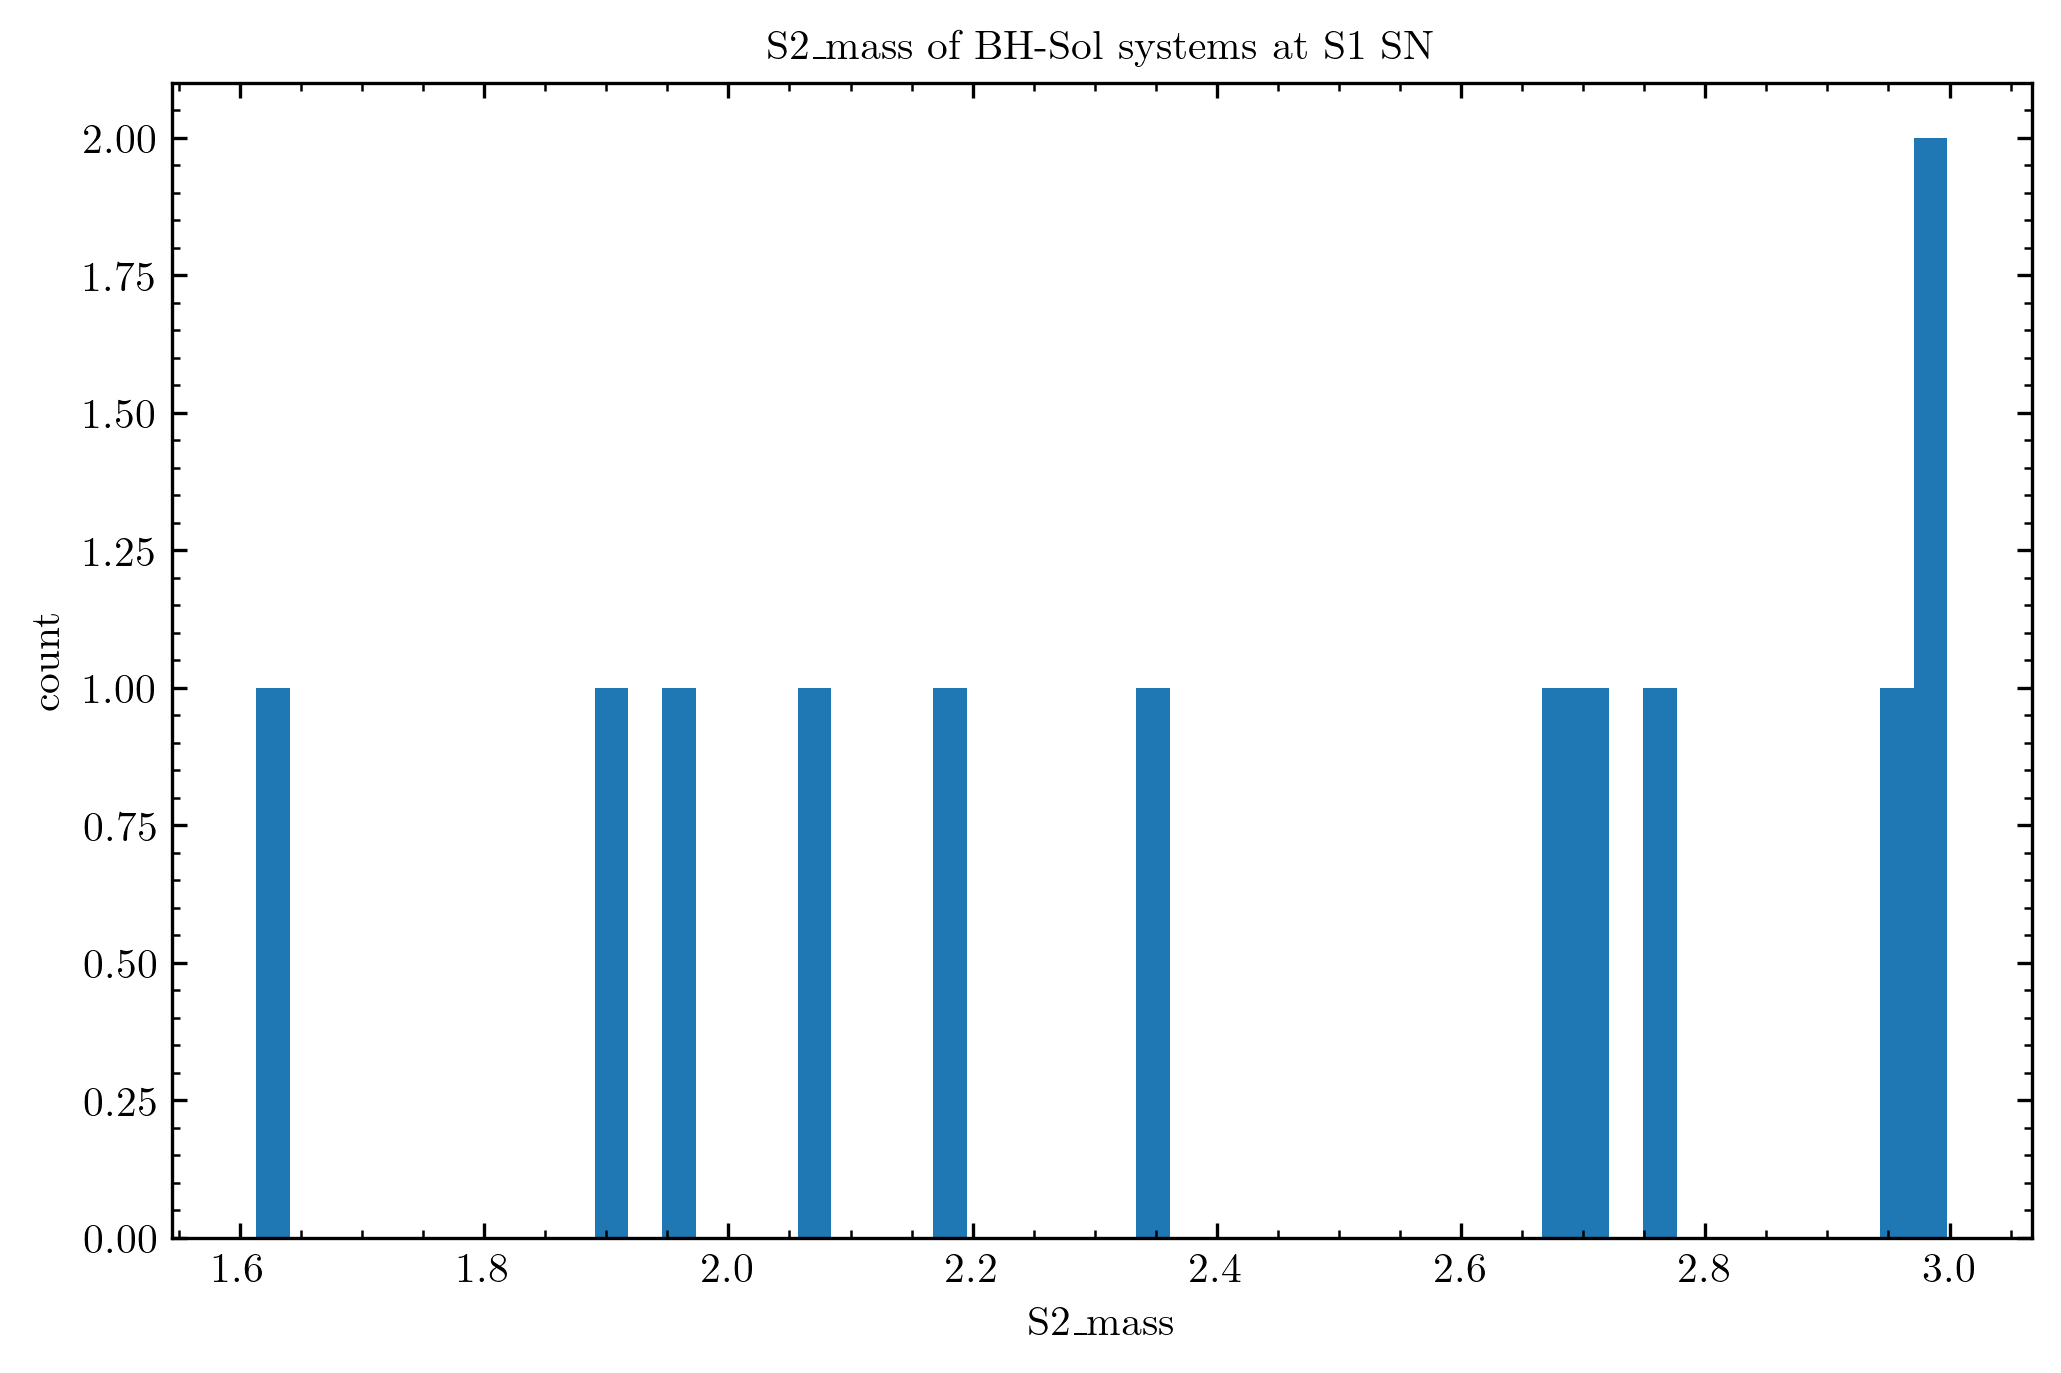

In [17]:
basicColHist(bhSolRows,'S2_mass')

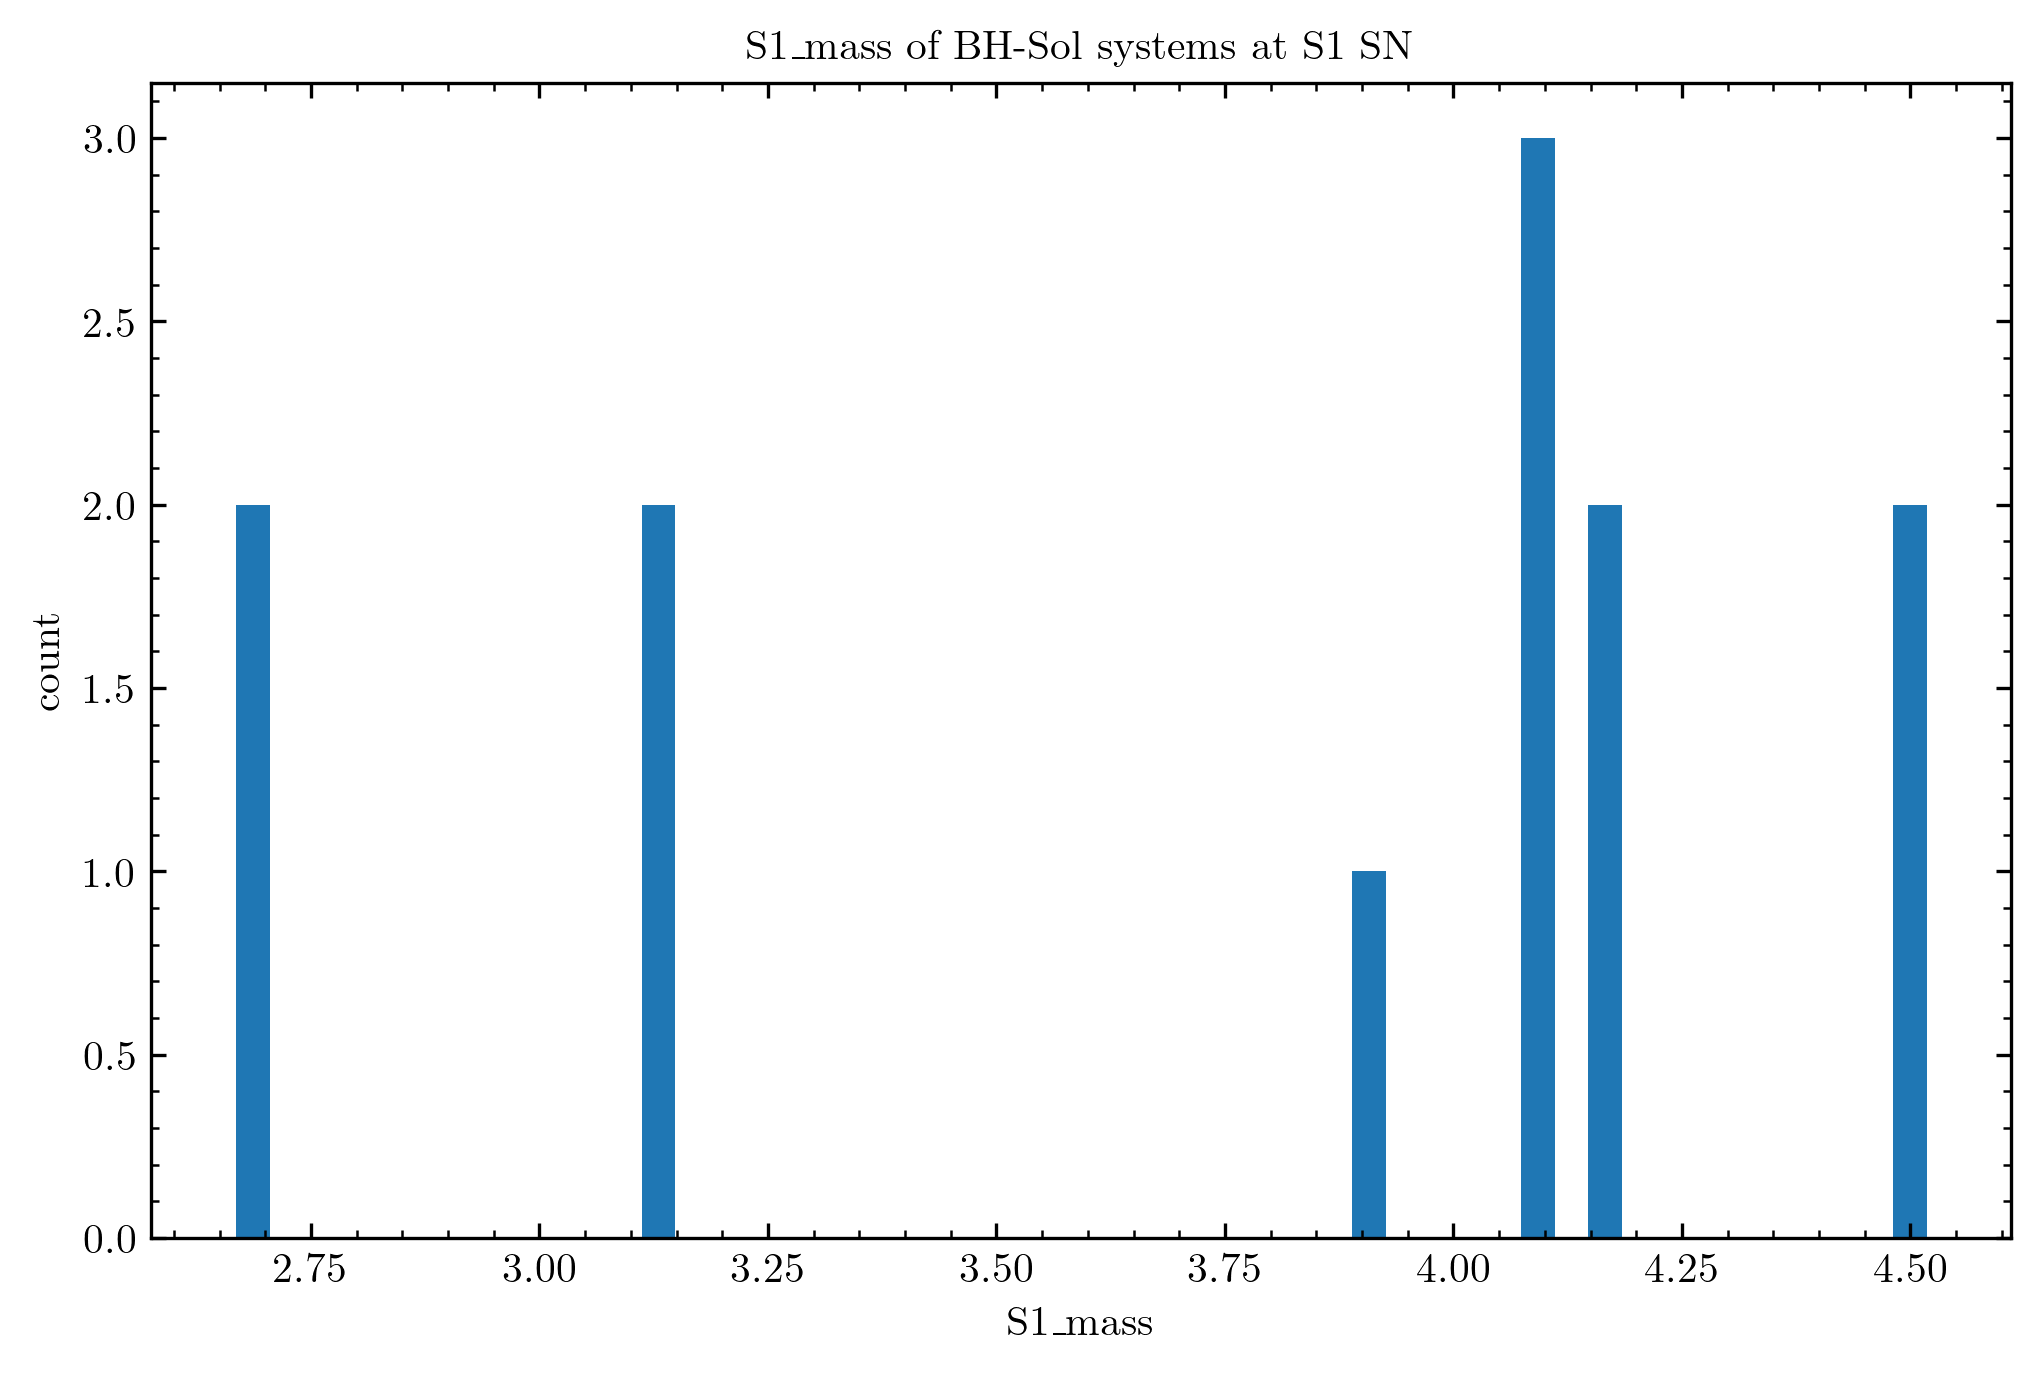

In [18]:
basicColHist(bhSolRows,'S1_mass')

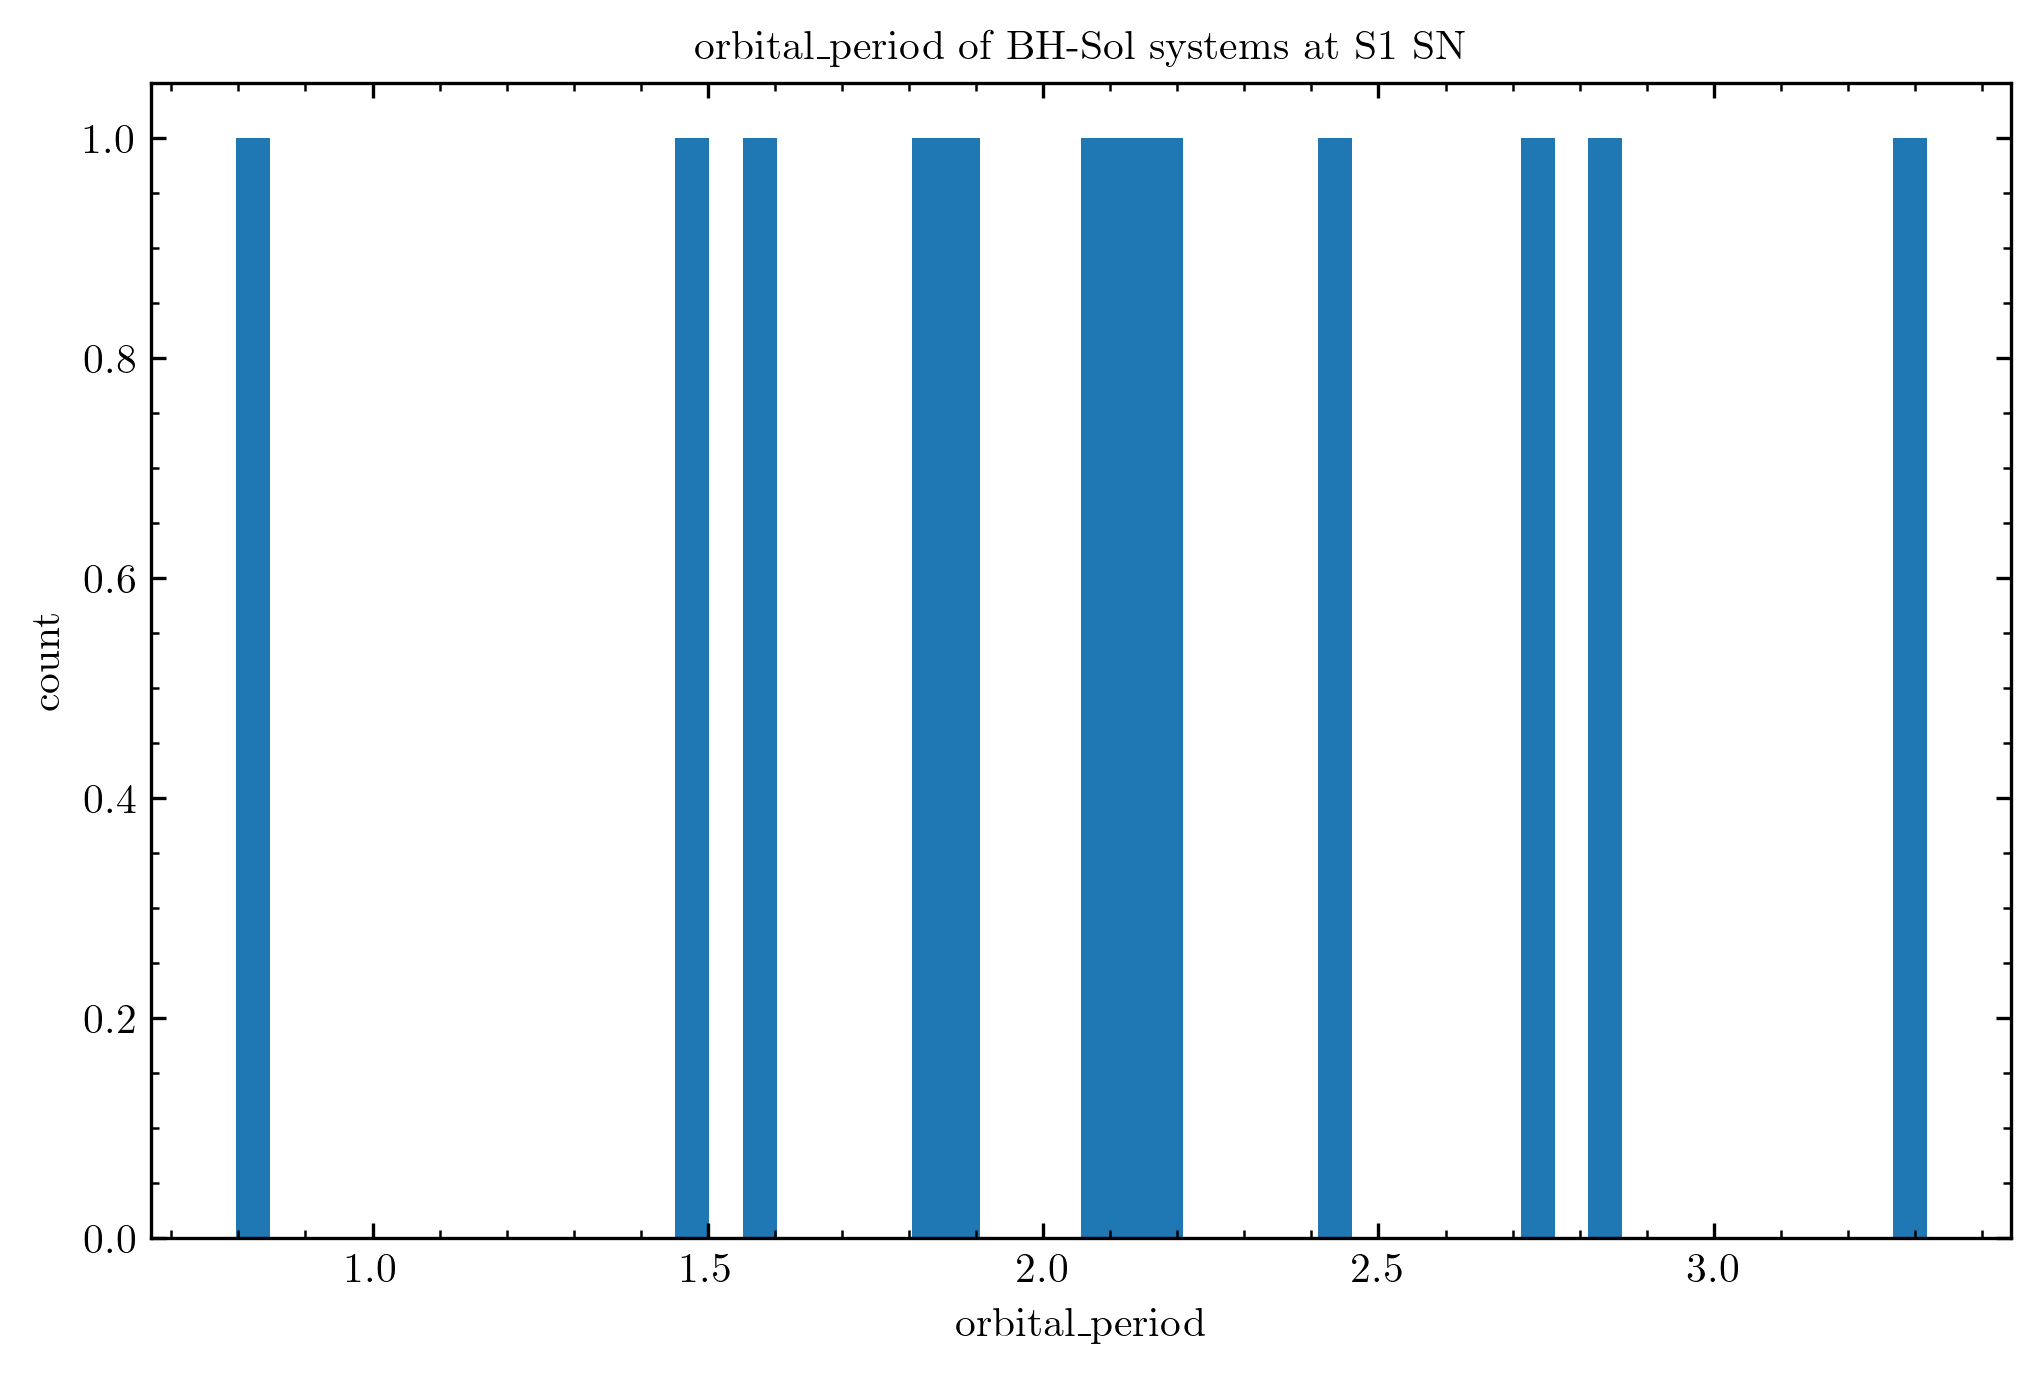

In [19]:
basicColHist(bhSolRows,'orbital_period', saveFig=True)


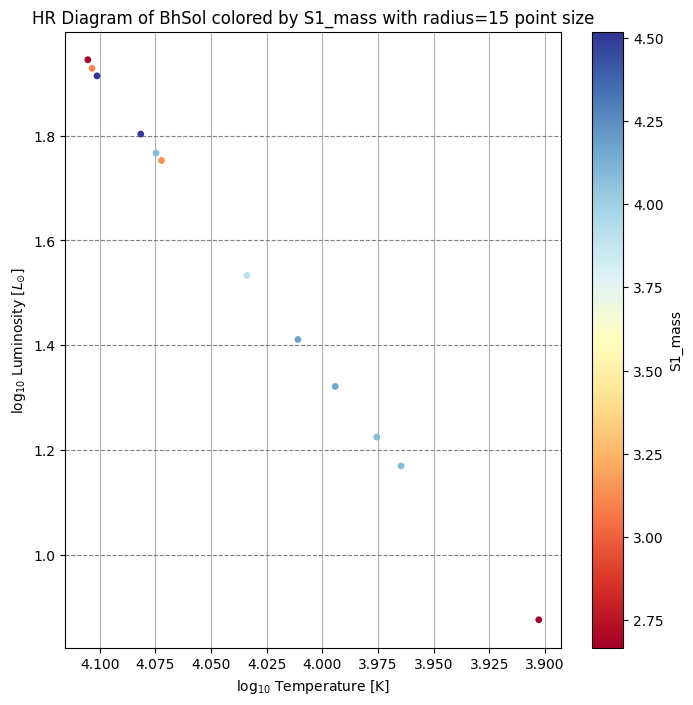

In [20]:
HR_Diagram(bhSolRows,
           'BhSol',
           Star_Radius=15)

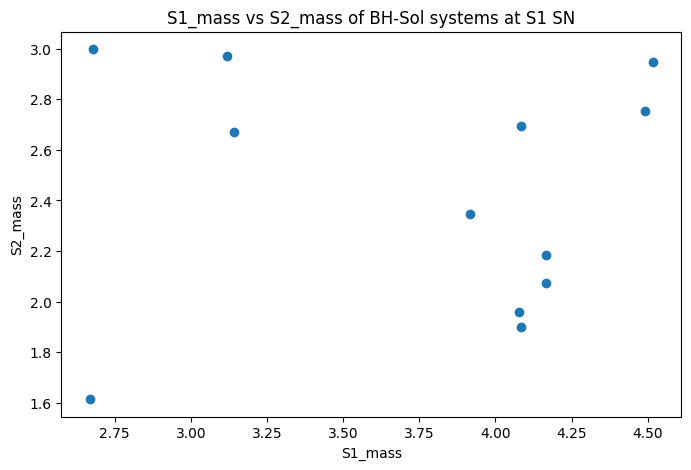

In [21]:
xVsY(bhSolRows, 'S1_mass', 'S2_mass')